# FO-UO Multimodal relationship fMRI & TSPO across costs and bootstrap
## AAL89

This notebook performs test F for the dataset using the AAL89 parcellation. It can be used for any other dataset, simply change the directories and variables accordingly (see attached comments).


Importing TSPO data

In [ ]:
import numpy as np
import networkx as nx
import scipy.special as ss
from networkx import tree
import os
import glob
def adj_matrix_connected(corr_matrix,sparsity_value):
    """given the correlation matrix and the expected sparsity coefficient it can 
    happen that the corresponding thresholded matrix results in a disconnected graph
    here we force the graph to be fully connected by the computation of the minimum
    spanning tree and adding the required edges in order to have a unique connected component 
    """
    if sparsity_value == 1.0:
        adj_matrix=np.ones(corr_matrix.shape)
        np.fill_diagonal(adj_matrix,0)
        return adj_matrix
        
    
    corr_matrix =abs(corr_matrix)

    max_num_edges = ss.comb(corr_matrix.shape[0],2)
    num_edges = int(max_num_edges*sparsity_value)
    
    num_regions=corr_matrix.shape[0]
    #total number of regions in the graph
        
    totalgraph=nx.from_numpy_array(1-abs(corr_matrix))
    #extraction of a complete graph having has weight 1-abs(correlation)
    #we need to take 1-abs since the mst is taking the minimum weight graph and we want the most correlated edges to be there
    
    MST=nx.to_numpy_array(tree.minimum_spanning_tree(totalgraph).to_undirected())
    MST_adj_mat=MST
    MST_adj_mat[MST>0]==1
    MST_adj_mat=np.triu(MST_adj_mat) #put zeros in the inferior triangular matrix
    
    #put zeros in the diagonal of the corr matrix
    for i in range(num_regions):
        corr_matrix[i,i]=0
    
    values_corr=abs(np.triu(corr_matrix))
    
    cor_wo_MST=values_corr[np.triu(MST_adj_mat)==0]
    #we do not consider the correlation values which do not involve edges that are already in the MST
    
    values=list(cor_wo_MST.flatten())
    values.sort(reverse=True)
    
    #we select the maximum value of correlation to have the expected num of edges - num of edges in the mst (num regions-1)
    value_thresh=values[num_edges-(num_regions-1)-1] #-1 index start at 0
    
    adj_matrix=np.zeros(corr_matrix.shape) 
    
    #we put an edge if the value of correlation is higher than the found threshold or if the edges is required by the mst
    adj_matrix[values_corr>=value_thresh]=1
    adj_matrix[MST_adj_mat!=0]=1
    
    adj_matrix=np.triu(adj_matrix)+np.transpose(np.triu(adj_matrix)) #simmetry of the adj matrix
    
    return adj_matrix


In [ ]:

controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]


tspo_matrix_path = "/Data/PET_Matrices/AAL" # Change accordingly 
list_tspo_cn = os.listdir(os.path.join(tspo_matrix_path, "Controls"))

controls_tspo_matrices = {}

for f in list_tspo_cn:
    #sub = 
    sub = f.split(".")[0]
    controls_tspo_matrices[sub] = np.loadtxt(os.path.join(tspo_matrix_path, "Controls", f), delimiter=",")

list_tspo_anox = os.listdir(os.path.join(tspo_matrix_path, "Anoxic"))

# anoxic_tspo_matrices = {}

# --- Subjects to exclude ---
excluded_anoxic = ["09CD"]  # Add any more if needed later

# --- Initialize container ---
anoxic_tspo_matrices = {}

# --- Load matrices, excluding unwanted IDs ---
for f in list_tspo_anox:
    sub = f.split(".")[0]  # extract subject ID (before .csv or .txt)
    
    if sub in excluded_anoxic:
        print(f"Skipping excluded subject: {sub}")
        continue  # skip loading this subject
    
    file_path = os.path.join(tspo_matrix_path, "Anoxic", f)
    anoxic_tspo_matrices[sub] = np.loadtxt(file_path, delimiter=",")

list_tspo_trau = os.listdir(os.path.join(tspo_matrix_path, "Traumatic"))

#traumatic_tspo_matrices = {}

# --- Subjects to exclude ---
excluded_traumatic = ["20MP", "25AY"]  # Add any more if needed later

# --- Initialize container ---
traumatic_tspo_matrices = {}

# --- Load matrices, excluding unwanted IDs ---
for f in list_tspo_trau:
    sub = f.split(".")[0]  # extract subject ID (before .csv or .txt)
    
    if sub in excluded_traumatic:
        print(f"Skipping excluded subject: {sub}")
        continue  # skip loading this subject
    
    file_path = os.path.join(tspo_matrix_path, "Traumatic", f)
    traumatic_tspo_matrices[sub] = np.loadtxt(file_path, delimiter=",")

import networkx as nx
import numpy as np
t_costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
#metrics_list = ['d', 'cc', 'cs'] # No betweenness!

controls_tspo_graphs = {cost:{sub: None for sub in controls_tspo_matrices.keys()} for cost in t_costs}
for cost in t_costs:
    for sub in controls_tspo_matrices.keys():
        controls_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(controls_tspo_matrices[sub], cost))

anoxic_tspo_graphs = {cost:{sub: None for sub in anoxic_tspo_matrices.keys()} for cost in t_costs}
for cost in t_costs:
    for sub in anoxic_tspo_matrices.keys():
            anoxic_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_tspo_matrices[sub], cost))

traumatic_tspo_graphs = {cost:{sub: None for sub in traumatic_tspo_matrices.keys()} for cost in t_costs}
for cost in t_costs:
    for sub in traumatic_tspo_matrices.keys():
        traumatic_tspo_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_tspo_matrices[sub], cost))

Skipping excluded subject: 09CD
Skipping excluded subject: 20MP
Skipping excluded subject: 25AY


hdi

In [ ]:
########## These functions are clean and precious !!! ##########

import numpy as np
import networkx as nx
from sklearn.linear_model import LinearRegression

def compute_baseline(graphs_dict, metric = "d"):
    """
    Compute baseline (mean degree or any metric per node) across all control graphs.
    graphs_dict: dict[sub_id -> nx.Graph]
    Returns: np.array of average degree/metric per node.
    """
    n_subjects = len(graphs_dict)
    example_sub = next(iter(graphs_dict.values()))
    n_regions = len(example_sub.nodes)
    metric_sum = np.zeros(n_regions)

    for sub, G in graphs_dict.items():
        if metric == "d":
            v = dict(nx.degree(G))
        elif metric == "cc":
            v = nx.clustering(G)
        elif metric == "cs":
            v = nx.closeness_centrality(G)
        else: 
            print("Error - metric not supported.")
            continue
        metric_sum += np.array([v[i] for i in range(n_regions)])

    baseline_metric = metric_sum / n_subjects
    return baseline_metric

# === HDI function, using precomputed graph dictionaries ===
def compute_HDI_ID(graphs_dict, baseline, metric="d"):
    """
    Compute HDI for a set of subject graphs, using a graph dictionary

    graphs_dict: dict[sub_id -> nx.Graph]
    baseline: np.array of control mean degree (or any node metric) per node

    Returns:
        list_subs: list of subject IDs
        res_HDI: np.array of HDI slopes
    """
    model = LinearRegression()
    list_subs = []
    res_HDI = np.zeros(len(graphs_dict))

    for i, sub in enumerate(graphs_dict.keys()):
        try:
            list_subs.append(sub)
            G = graphs_dict[sub]
            if metric == "d":
                v = dict(nx.degree(G))
            elif metric == "cc":
                v = nx.clustering(G)
            elif metric == "cs":
                v = nx.closeness_centrality(G)
            else:
                print("Error - metric not supported.")
                continue
            vv = np.array(list(v.items()))  # same as original
            subj = vv[:, 1] - baseline
            x = baseline.reshape((-1, 1))
            y = subj
            model.fit(x, y)
            res_HDI[i] = model.coef_[0]
        except Exception as e:
            print(f"Error processing {sub}: {e}")
            res_HDI[i] = np.nan

    return list_subs, res_HDI



In [ ]:
favorable_group = ["06BM", "11FC", "12LY", "13TL", "14RC", "15GL", "18BE", "22BT", "23GC","24ZX", "25AY", "26AC"] # high CRS score
unfavorable_group = ["01JF", "02PD", "03DB", "04CD", "05ME","07TA","08PE","09CD","10CP","16FF","17MC","20MP","21GT"] # low CRS score or décès 


In [ ]:
# === HDI per subject, cost, and metric ===

metrics = ["d"]
costs = t_costs

# === Containers ===
baseline_metrics_tspo = {m: {} for m in metrics}  # baseline metric per cost per metric
HDI_results_tspo = {
    c: {m: {"Controls": {}, "Coma": {}} for m in metrics}
    for c in costs
}  # cost / metric / group / subject / HDI

# === Compute baseline metrics from controls ===
for cost in costs:
    for metric in metrics:
        baseline_metrics_tspo[metric][cost] = compute_baseline(controls_tspo_graphs[cost], metric)
        print(f"Computed baseline for cost {cost}, metric {metric}")


Computed baseline for cost 0.05, metric d
Computed baseline for cost 0.1, metric d
Computed baseline for cost 0.15, metric d
Computed baseline for cost 0.2, metric d
Computed baseline for cost 0.25, metric d
Computed baseline for cost 0.3, metric d
Computed baseline for cost 0.35, metric d
Computed baseline for cost 0.4, metric d
Computed baseline for cost 0.45, metric d
Computed baseline for cost 0.5, metric d


fmri

In [ ]:

controls_aal = [
    "01FO", "02LE", "03GA", "04GM", "05IM", "07NA", "08CP", "09DM", "11GL", "12LJ",
    "13AE", "14PM", "15GT", "16DT", "17LY", "19DG", "20CP", "21LJ", "22DD", "23BA"
]

anoxic_aal = [ # Effective Anoxic patients
    "01JF", "02PD", "06BM", "07TA", "14RC"
]
traumatic_aal = [  # Effective Traumatic patients  - Patient 08PE must be excluded from studies using AICHA 
    "03DB", "08PE", "11FC", "13TL", "16FF", "22BT", "23GC", "24ZX", "26AC"
]

matrices_path =  "/Data/Correlation_Matrices/AAL" # Simply change the last path to import other atlases, e.g. AICHA
control_path = os.path.join(matrices_path, "Controls")
anoxic_path = os.path.join(matrices_path, "Anoxic")
traumatic_path = os.path.join(matrices_path, "Traumatic")

# Final filter before importing - matching IDs from lists to files to exclude non-effective subjects

control_subjects = sorted(
    s for s in glob.glob(os.path.join(control_path, "*"))
    if os.path.basename(s).split(".")[0] in controls_aal
)

anoxic_subjects = sorted(
    s for s in glob.glob(os.path.join(anoxic_path, "*"))
    if os.path.basename(s).split(".")[0] in anoxic_aal
)

traumatic_subjects = sorted(
    s for s in glob.glob(os.path.join(traumatic_path, "*"))
    if os.path.basename(s).split(".")[0] in traumatic_aal
)

# Importing correlations - Keys are IDs, values are matrices

control_correlations = {}
for sub in control_subjects:
    control_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)


traumatic_correlations = {}
for sub in traumatic_subjects:
    traumatic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

anoxic_correlations = {}
for sub in anoxic_subjects:
    anoxic_correlations[os.path.splitext(os.path.basename(sub))[0]] = np.loadtxt(sub)

print(f"Controls: {len(control_correlations.keys())}, Anoxic: {len(anoxic_correlations.keys())}, Traumatic: {len(traumatic_correlations.keys())}")

# Constructing fMRI graphs

costs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

controls_fmri_graphs = {cost:{sub: None for sub in control_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in control_correlations.keys(): # Keys are IDs, values are nx.Graph objects
        controls_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(control_correlations[sub], cost))

anoxic_fmri_graphs = {cost:{sub: None for sub in anoxic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in anoxic_correlations.keys():
        anoxic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(anoxic_correlations[sub], cost))

traumatic_fmri_graphs = {cost:{sub: None for sub in traumatic_correlations.keys()} for cost in costs}
for cost in costs:
    for sub in traumatic_correlations.keys():
        traumatic_fmri_graphs[cost][sub] = nx.from_numpy_array(adj_matrix_connected(traumatic_correlations[sub], cost))

# We can merge the coma dataset in one dictionary

coma_fmri_graphs = {cost: {} for cost in costs}

for cost in costs:
    coma_fmri_graphs[cost] = {**anoxic_fmri_graphs[cost], **traumatic_fmri_graphs[cost]}


Controls: 20, Anoxic: 5, Traumatic: 9


In [5]:
# === HDI per subject, cost, and metric ===

metrics = ["d"]
#costs = [0.05, 0.1]

# === Containers ===
baseline_metrics_fmri = {m: {} for m in metrics}  # baseline metric per cost per metric
HDI_results_fmri = {
    c: {m: {"Controls": {}, "Coma": {}} for m in metrics}
    for c in costs
}  # cost / metric / group / subject / HDI

# === Compute baseline metrics from controls ===
for cost in costs:
    for metric in metrics:
        baseline_metrics_fmri[metric][cost] = compute_baseline(controls_fmri_graphs[cost], metric)
        print(f"Computed baseline for cost {cost}, metric {metric}")

print("\nAll HDI computations complete.")


Computed baseline for cost 0.05, metric d
Computed baseline for cost 0.1, metric d
Computed baseline for cost 0.15, metric d
Computed baseline for cost 0.2, metric d
Computed baseline for cost 0.25, metric d
Computed baseline for cost 0.3, metric d
Computed baseline for cost 0.35, metric d
Computed baseline for cost 0.4, metric d
Computed baseline for cost 0.45, metric d
Computed baseline for cost 0.5, metric d

All HDI computations complete.


Differences FO/UO Across costs

In [6]:
coma_tspo_graphs = {}
for cost in costs:
    coma_tspo_graphs[cost] = {**anoxic_tspo_graphs[cost], **traumatic_tspo_graphs[cost]}

favorable_group = ["06BM", "11FC", "12LY", "13TL", "14RC", "15GL", "18BE", "22BT", "23GC","24ZX", "25AY", "26AC"] # a one in the table, meaning that the subject survived and had a high CRS score
unfavorable_group = ["01JF", "02PD", "03DB", "04CD", "05ME","07TA","08PE","09CD","10CP","16FF","17MC","20MP","21GT"] # zero on the table, subject didn't survive or a low CRS score
favorable_multimodal = list(set(favorable_group).intersection(set(coma_fmri_graphs[0.1].keys())))
unfavorable_multimodal = list(set(unfavorable_group).intersection(set(coma_fmri_graphs[0.1].keys())))



`degree_fo_fmri`: Node degree in the favorable outcome group, fMRI graphs
`degree_uo_fmri`: Node degree in the favorable outcome group, TSPO graphs

Identical structure for UO

In [ ]:
degree_fo_fmri = {}
degree_uo_fmri = {}

for cost in costs:
    degree_regions_fo_fmri = np.zeros(89) # Change according to used atlas
    degree_regions_uo_fmri = np.zeros(89)

    for sub in coma_fmri_graphs[0.1].keys():
        if sub in favorable_multimodal:
            vv = np.array(list(dict(coma_fmri_graphs[cost][sub].degree).values()))
            degree_regions_fo_fmri+=vv
    
        elif sub in unfavorable_multimodal:
            vv = np.array(list(dict(coma_fmri_graphs[cost][sub].degree).values()))
            degree_regions_uo_fmri+=vv

    degree_regions_fo_fmri /= len(favorable_multimodal)
    degree_regions_uo_fmri /= len(unfavorable_multimodal)
    # now we simply store it their dictionaries
    degree_fo_fmri[cost] = degree_regions_fo_fmri
    degree_uo_fmri[cost] = degree_regions_uo_fmri



In [9]:
degree_fo_tspo = {}
degree_uo_tspo = {}

for cost in costs:

    degree_regions_fo_tspo = np.zeros(89)
    degree_regions_uo_tspo = np.zeros(89)

    for sub in coma_tspo_graphs[0.1].keys():
        if sub in favorable_group:
            vv = np.array(list(dict(coma_tspo_graphs[cost][sub].degree).values()))
            degree_regions_fo_tspo+=vv
    
        elif sub in unfavorable_group:
            vv = np.array(list(dict(coma_tspo_graphs[cost][sub].degree).values()))
            degree_regions_uo_tspo+=vv

    degree_regions_fo_tspo /= len(favorable_multimodal)
    degree_regions_uo_tspo /= len(unfavorable_multimodal)

    # now we simply store it their dictionaries
    degree_fo_tspo[cost] = degree_regions_fo_tspo
    degree_uo_tspo[cost] = degree_regions_uo_tspo





`y_fmri_fo_cost`: Stores the difference in fMRI degree of FO patients relative to healthy controls (baseline group). 

In [11]:
y_fmri_fo_costs = {}
y_tspo_fo_costs = {}

y_fmri_uo_costs = {}
y_tspo_uo_costs = {}

for cost in costs:
    baseline_degree_fmri = baseline_metrics_fmri['d'][cost]
    baseline_degree_tspo = baseline_metrics_tspo['d'][cost]

    # Favorable - Difference of mean degree with controls at different costs
    y_fmri_fo_costs[cost] = degree_fo_fmri[cost] - baseline_degree_fmri
    y_tspo_fo_costs[cost] = degree_fo_tspo[cost] - baseline_degree_tspo
    
    # Unfavorable - Difference of mean degree with controls at different costs
    y_fmri_uo_costs[cost] = degree_uo_fmri[cost] - baseline_degree_fmri
    y_tspo_uo_costs[cost] = degree_uo_tspo[cost] - baseline_degree_tspo


Result for graphs at 10% density

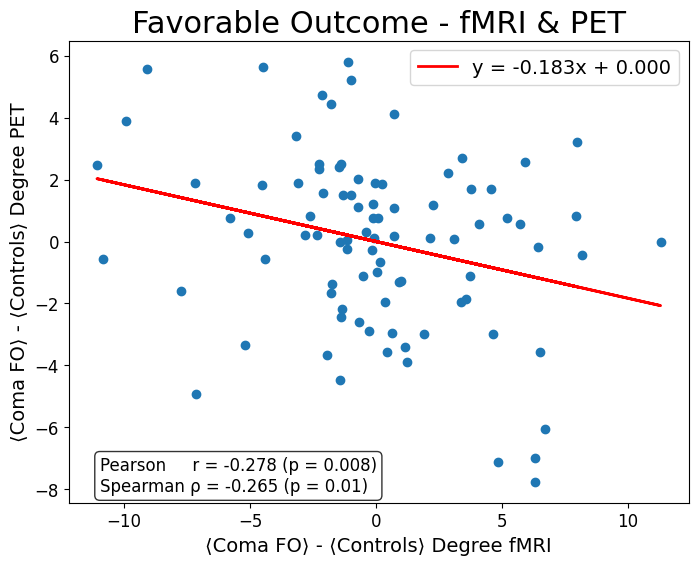

In [14]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Fit regression
model = LinearRegression()
x = y_fmri_fo_costs[0.1].reshape(-1,1)
y = y_tspo_fo_costs[0.1]
model.fit(x,y)
y_pred = model.predict(x)

# ---- Statistics ----
r2 = r2_score(y, y_pred)
pearson_r, pearson_p = pearsonr( y_fmri_fo_costs[0.1], y_tspo_fo_costs[0.1])
spearman_r, spearman_p = spearmanr( y_fmri_fo_costs[0.1], y_tspo_fo_costs[0.1])

# ---- Plot ----
plt.figure(figsize=(8,6))

# Regression line
plt.plot(x, y_pred, color='red', linewidth=2,
         label=f"y = {model.coef_[0]:.3f}x + {model.intercept_:.3f}")

# Scatter
plt.scatter(x, y)

# Text box with statistics
stats_text = (
    #f"$R^2$ = {r2:.3f}\n"
    f"Pearson     r = {pearson_r:.3f} (p = {pearson_p:.1g})\n"
    f"Spearman ρ = {spearman_r:.3f} (p = {spearman_p:.1g})"
)

plt.text(
    0.05, 0.1, stats_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.title("Favorable Outcome - fMRI & PET", fontsize=22)
plt.xlabel("⟨Coma FO⟩ - ⟨Controls⟩ Degree fMRI", fontsize=14)
plt.ylabel("⟨Coma FO⟩ - ⟨Controls⟩ Degree PET", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=14)

#plt.savefig("/home/cabrerar/Documents/Paper_1/Figures_outcomes/FO fMRI and PET.png", dpi=300)
plt.show()

Now we simply need to repeat this process for every group, at every cost.

In [16]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


results_fo = []
for cost in costs:
    # Fit regression
    model = LinearRegression()
    x = y_fmri_fo_costs[cost].reshape(-1,1)
    y = y_tspo_fo_costs[cost]
    model.fit(x,y)
    y_pred = model.predict(x)

    # ---- Statistics ----
    r2 = r2_score(y, y_pred)
    pearson_r, pearson_p = pearsonr( y_fmri_fo_costs[cost], y_tspo_fo_costs[cost])
    spearman_r, spearman_p = spearmanr( y_fmri_fo_costs[cost], y_tspo_fo_costs[cost])
    results_fo.append({
        "Cost": cost,
        "Coefficient": model.coef_[0],
        "R^2": r2,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p
    }
    )
results_fo_pd = pd.DataFrame(results_fo)
results_fo_pd


,Cost,Coefficient,R^2,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,0.05,-0.246839,0.144718,-0.380418,0.000236,-0.422636,0.000037
1,0.10,-0.183036,0.077305,-0.278038,0.008336,-0.265321,0.011976
2,0.15,-0.173733,0.074261,-0.272509,0.009778,-0.225991,0.033214
3,0.20,-0.164326,0.058739,-0.242361,0.022118,-0.196455,0.065011
4,0.25,-0.197498,0.076210,-0.276062,0.008828,-0.233303,0.027784
5,0.30,-0.206802,0.074152,-0.272308,0.009834,-0.247810,0.019210
6,0.35,-0.223601,0.078750,-0.280624,0.007728,-0.256826,0.015118
7,0.40,-0.229421,0.081529,-0.285533,0.006681,-0.294364,0.005109
8,0.45,-0.203180,0.061905,-0.248808,0.018715,-0.253580,0.016494
9,0.50,-0.160733,0.038067,-0.195107,0.066912,-0.206619,0.052052


Multimodal FO anticorrelation is robust to graph density

In [17]:
results_uo = []
for cost in costs:
    # Fit regression
    model = LinearRegression()
    x = y_fmri_uo_costs[cost].reshape(-1,1)
    y = y_tspo_uo_costs[cost]
    model.fit(x,y)
    y_pred = model.predict(x)

    # ---- Statistics ----
    r2 = r2_score(y, y_pred)
    pearson_r, pearson_p = pearsonr( y_fmri_uo_costs[cost], y_tspo_uo_costs[cost])
    spearman_r, spearman_p = spearmanr( y_fmri_uo_costs[cost], y_tspo_uo_costs[cost])
    results_uo.append({
        "Cost": cost,
        "Coefficient": model.coef_[0],
        "R^2": r2,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p
    }
    )
results_uo_pd = pd.DataFrame(results_uo)
results_uo_pd


,Cost,Coefficient,R^2,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,0.05,-0.026053,0.002348,-0.048459,0.652017,-0.123917,0.247283
1,0.10,-0.032003,0.003409,-0.058390,0.586766,-0.055644,0.604511
2,0.15,-0.034074,0.003979,-0.063080,0.557024,-0.019536,0.855810
3,0.20,-0.044278,0.005485,-0.074062,0.490337,-0.028086,0.793883
4,0.25,-0.047986,0.005835,-0.076389,0.476768,-0.022949,0.830959
5,0.30,-0.045169,0.004699,-0.068550,0.523273,-0.025971,0.809103
6,0.35,-0.074903,0.010905,-0.104425,0.330114,-0.064011,0.551204
7,0.40,-0.104455,0.020409,-0.142860,0.181696,-0.111705,0.297323
8,0.45,-0.114516,0.020587,-0.143483,0.179781,-0.089497,0.404252
9,0.50,-0.119373,0.020025,-0.141510,0.185903,-0.064471,0.548341


Let's save these results 

In [ ]:
results_fo_pd.to_csv("/F/AAL89_FO_degree_multimodal_costs.csv", index=False)

In [ ]:
results_uo_pd.to_csv("/F/AAL89_UO_degree_multimodal_costs.csv", index=False)

# Bootstrap tests


In [ ]:

n_bootstrap = 10000

# Get subject lists per group
fmri_subjects = list(coma_fmri_graphs[0.1].keys())
tspo_subjects = list(coma_tspo_graphs[0.1].keys())

fo_fmri_subs = [s for s in fmri_subjects if s in favorable_multimodal]
uo_fmri_subs = [s for s in fmri_subjects if s in unfavorable_multimodal]
fo_tspo_subs = [s for s in tspo_subjects if s in favorable_group]
uo_tspo_subs = [s for s in tspo_subjects if s in unfavorable_group]

bootstrap_results = []
#bootstrap_uo_results = []

for cost in costs: 
    # we need a baseline per cost!
    baseline_degree_fmri = baseline_metrics_fmri['d'][cost]
    baseline_degree_tspo = baseline_metrics_tspo['d'][cost]

    boot_corr_fo = np.zeros(n_bootstrap)
    boot_corr_uo = np.zeros(n_bootstrap)

    for i in range(n_bootstrap):
        # --- Resample ONE set of indices, applied to both modalities ---
        boot_fo_idx = np.random.choice(len(fo_fmri_subs), size=len(fo_fmri_subs), replace=True)
        boot_uo_idx = np.random.choice(len(uo_fmri_subs), size=len(uo_fmri_subs), replace=True)

        boot_fo_subs = [fo_fmri_subs[j] for j in boot_fo_idx]
        boot_uo_subs = [uo_fmri_subs[j] for j in boot_uo_idx]

        # --- Same subjects used for both fMRI and TSPO ---
        deg_fo_fmri = np.mean([
            np.array(list(dict(coma_fmri_graphs[cost][s].degree).values()))
            for s in boot_fo_subs], axis=0)

        deg_fo_tspo = np.mean([
            np.array(list(dict(coma_tspo_graphs[cost][s].degree).values()))
            for s in boot_fo_subs], axis=0)  # <-- same boot_fo_subs, not boot_fo_tspo

        deg_uo_fmri = np.mean([
            np.array(list(dict(coma_fmri_graphs[cost][s].degree).values()))
            for s in boot_uo_subs], axis=0)

        deg_uo_tspo = np.mean([
            np.array(list(dict(coma_tspo_graphs[cost][s].degree).values()))
            for s in boot_uo_subs], axis=0)  # <-- same boot_uo_subs


        # --- Subtract baseline ---
        y_fmri_fo_b = deg_fo_fmri - baseline_degree_fmri
        y_tspo_fo_b = deg_fo_tspo - baseline_degree_tspo
        y_fmri_uo_b = deg_uo_fmri - baseline_degree_fmri
        y_tspo_uo_b = deg_uo_tspo - baseline_degree_tspo

        # --- Compute correlations ---
        boot_corr_fo[i], _ = pearsonr(y_fmri_fo_b, y_tspo_fo_b)
        boot_corr_uo[i], _ = pearsonr(y_fmri_uo_b, y_tspo_uo_b)

    # --- 95% CIs ---
    ci_fo = np.percentile(boot_corr_fo, [2.5, 97.5])
    ci_uo = np.percentile(boot_corr_uo, [2.5, 97.5])

    # --- CI on the difference ---
    boot_diff = boot_corr_fo - boot_corr_uo
    ci_diff = np.percentile(boot_diff, [2.5, 97.5])
    
    bootstrap_results.append({
        "Cost": cost,
        "Mean_FO_Correlation": boot_corr_fo.mean(),
        "95%_CI_FO": ci_fo,
        "Mean_UO_Correlation": boot_corr_uo.mean(),
        "95%_CI_UO": ci_uo,
        "Difference_FO-UO": boot_diff.mean(),
        "95%_CI_Diff": ci_diff
    })

In [25]:
bootstrap_results_df = pd.DataFrame(bootstrap_results)
bootstrap_results_df

,Cost,Mean_FO_Correlation,95%_CI_FO,Mean_UO_Correlation,95%_CI_UO,Difference_FO-UO,95%_CI_Diff
0,0.05,-0.288463,"[-0.4087463680155164, -0.1304337743007598]",0.019211,"[-0.0843535225127788, 0.22273507557314817]",-0.307674,"[-0.5479141746644152, -0.10611321725226802]"
1,0.10,-0.204842,"[-0.35728171336340625, -0.04675069062019234]",-0.003666,"[-0.12759394714974964, 0.19064074730027658]",-0.201177,"[-0.4489589062505267, 0.010955424479852989]"
2,0.15,-0.202236,"[-0.35568637032978206, -0.055631272765947454]",-0.000450,"[-0.12376599562108692, 0.23709919011521632]",-0.201786,"[-0.47200840552890594, 0.010242168774848]"
3,0.20,-0.177030,"[-0.34913732996143143, -0.02545090942051538]",-0.004806,"[-0.11723238525187778, 0.2576796808011792]",-0.172224,"[-0.4648560028527818, 0.03628174280180737]"
4,0.25,-0.209783,"[-0.3671880459985519, -0.06435290736807282]",-0.011640,"[-0.16398629649697027, 0.27771472703206085]",-0.198143,"[-0.5113392083167856, 0.02837822373034651]"
5,0.30,-0.204229,"[-0.36300296056005715, -0.05102072453028434]",-0.007972,"[-0.18770362373815394, 0.29440328663937765]",-0.196257,"[-0.5241882362727532, 0.04476969267384948]"
6,0.35,-0.211987,"[-0.3588287654600588, -0.0690598276118285]",-0.042698,"[-0.19565882005807644, 0.24094096938721016]",-0.169289,"[-0.46689709926781103, 0.051617752073900396]"
7,0.40,-0.214846,"[-0.3817984095704723, -0.05705626101425586]",-0.074657,"[-0.21797186008372224, 0.17008519111400305]",-0.140189,"[-0.4265142479177356, 0.08729581312055629]"
8,0.45,-0.191268,"[-0.35756141096347804, -0.031429192255703724]",-0.088378,"[-0.2109900553028279, 0.09643498153312972]",-0.102890,"[-0.34192627095963135, 0.10337631751893091]"
9,0.50,-0.149403,"[-0.3157056256537519, 0.015604176123553682]",-0.087357,"[-0.20329588991034975, 0.06901078621717477]",-0.062047,"[-0.28933311000110984, 0.14936310070690748]"


We export it

In [ ]:
bootstrap_results_df.to_csv("/F/AAL89_Bootstrap_FO_UO.csv", index=False)

And now we simply repeat for all other atlases.